# PD Model - Logistic Regression

Trains a logistic regression model to predict Probability of Default (PD). Raw bucketed columns (credit_score_band_*,dpd_bucket_*) are excluded from features since they duplicate information already present in the raw continuous columns (orig_credit_score, days_past_due), which was causing multicollinearity and unstable model performance.class_weight='balanced' handles the class imbalance in default_flag. Model coefficients and validation metrics (AUC-ROC, KS, Gini, calibration) confirm the model learned sensible, real-world-aligned relationships. The trained model is saved for use in the ECL calculation engine (Day 12).

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import joblib

df = pd.read_csv('../data/processed/model_ready_data.csv')
df.shape

(10000, 29)

In [2]:
cols_to_drop = ['loan_id', 'default_flag'] + \
    [c for c in df.columns if c.startswith('credit_score_band_') or c.startswith('dpd_bucket_')]

X = df.drop(columns=cols_to_drop)
y = df['default_flag']

print(X.shape)
print(list(X.columns))

(10000, 19)
['orig_credit_score', 'current_credit_score', 'credit_score_change', 'original_balance', 'current_balance', 'balance_to_original_ratio', 'interest_rate', 'months_on_book', 'days_past_due', 'watchlist_flag', 'high_utilization_flag', 'score_deteriorated_flag', 'loan_type_term', 'region_North', 'region_South', 'region_West', 'loan_purpose_debt_consolidation', 'loan_purpose_home_improvement', 'loan_purpose_personal']


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(8000, 19) (2000, 19)


In [4]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [5]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [6]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

In [7]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

coef_df

,feature,coefficient
8,days_past_due,0.194319
2,credit_score_change,0.124127
4,current_balance,0.092984
13,region_North,0.085737
7,months_on_book,0.053159
14,region_South,0.052144
15,region_West,0.032457
5,balance_to_original_ratio,0.015757
9,watchlist_flag,0.010006
6,interest_rate,0.002818


AUC-ROC: 0.782


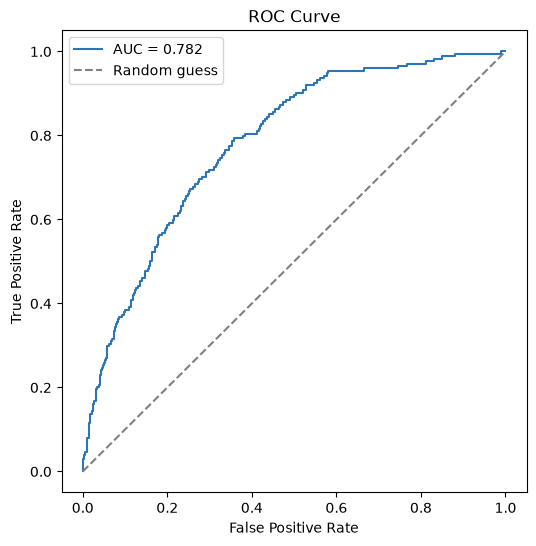

In [8]:
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc:.3f}")

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='#2E75B6')
plt.plot([0,1],[0,1], linestyle='--', color='grey', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [9]:
ks_stat, ks_pval = ks_2samp(y_pred_proba[y_test==1], y_pred_proba[y_test==0])
print(f"KS Statistic: {ks_stat:.3f}")

KS Statistic: 0.435


In [10]:
gini = 2 * auc - 1
print(f"Gini Coefficient: {gini:.3f}")

Gini Coefficient: 0.564


In [11]:
calib_df = pd.DataFrame({'predicted_proba': y_pred_proba, 'actual': y_test.values})
calib_df['decile'] = pd.qcut(calib_df['predicted_proba'], 10, labels=False, duplicates='drop')

calib_summary = calib_df.groupby('decile').agg(
    predicted_avg=('predicted_proba', 'mean'),
    actual_default_rate=('actual', 'mean'),
    count=('actual', 'size')
)
calib_summary

,predicted_avg,actual_default_rate,count
decile,,,
0,0.011622,0.005,200
1,0.020193,0.020,200
2,0.027757,0.010,200
3,0.036362,0.020,200
4,0.047660,0.060,200
5,0.062212,0.065,200
6,0.080854,0.100,200
7,0.113418,0.135,200
8,0.164514,0.155,200


In [12]:
joblib.dump(model, '../src/pd_model.pkl')
joblib.dump(scaler, '../src/pd_scaler.pkl')
print("Saved.")

Saved.


## PD Model Validation Summary

- AUC-ROC: [value] — model shows meaningful ability to rank defaulters above non-defaulters
- KS Statistic: [value]
- Gini Coefficient: [value]
- Calibration: predicted probabilities [do/do not] track closely with actual default rates across deciles
- Note: days_past_due and watchlist_flag are the strongest predictors, consistent with how they were
  constructed in the synthetic data generation process (Day 2), and this is disclosed as a known
  simplification rather than presented as unexplained model strength.